In [ ]:
import gdown
url = "https://drive.google.com/uc?id=1TTm6Up5BKuOOTi-4MS96cFaYcWYL73qi"
output = "CustomerDataSet.csv"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1TTm6Up5BKuOOTi-4MS96cFaYcWYL73qi
To: /content/CustomerDataSet.csv
100%|██████████| 425k/425k [00:00<00:00, 69.7MB/s]


'CustomerDataSet.csv'

In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("CustomerDataSet.csv")
df.head(10)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C
7,464347,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6,D
8,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7,D
9,465176,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6,C


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [ ]:
#numerical
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(numerical_cols)

Index(['ID', 'Age', 'Work_Experience', 'Family_Size'], dtype='object')


In [ ]:
#categorical
categorical_cols = df.select_dtypes(include=['object']).columns
print(categorical_cols)

Index(['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score',
       'Var_1', 'Segmentation'],
      dtype='object')


In [ ]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
ID,8068.0,463479.214551,2595.381232,458982.0,461240.75,463472.5,465744.25,467974.0
Age,8068.0,43.466906,16.711696,18.0,30.00,40.0,53.00,89.0
Work_Experience,7239.0,2.641663,3.406763,0.0,0.00,1.0,4.00,14.0
Family_Size,7733.0,2.850123,1.531413,1.0,2.00,3.0,4.00,9.0


In [ ]:
df[categorical_cols].describe().T

,count,unique,top,freq
Gender,8068,2,Male,4417
Ever_Married,7928,2,Yes,4643
Graduated,7990,2,Yes,4968
Profession,7944,9,Artist,2516
Spending_Score,8068,3,Low,4878
Var_1,7992,7,Cat_6,5238
Segmentation,8068,4,D,2268


Data Visualisation

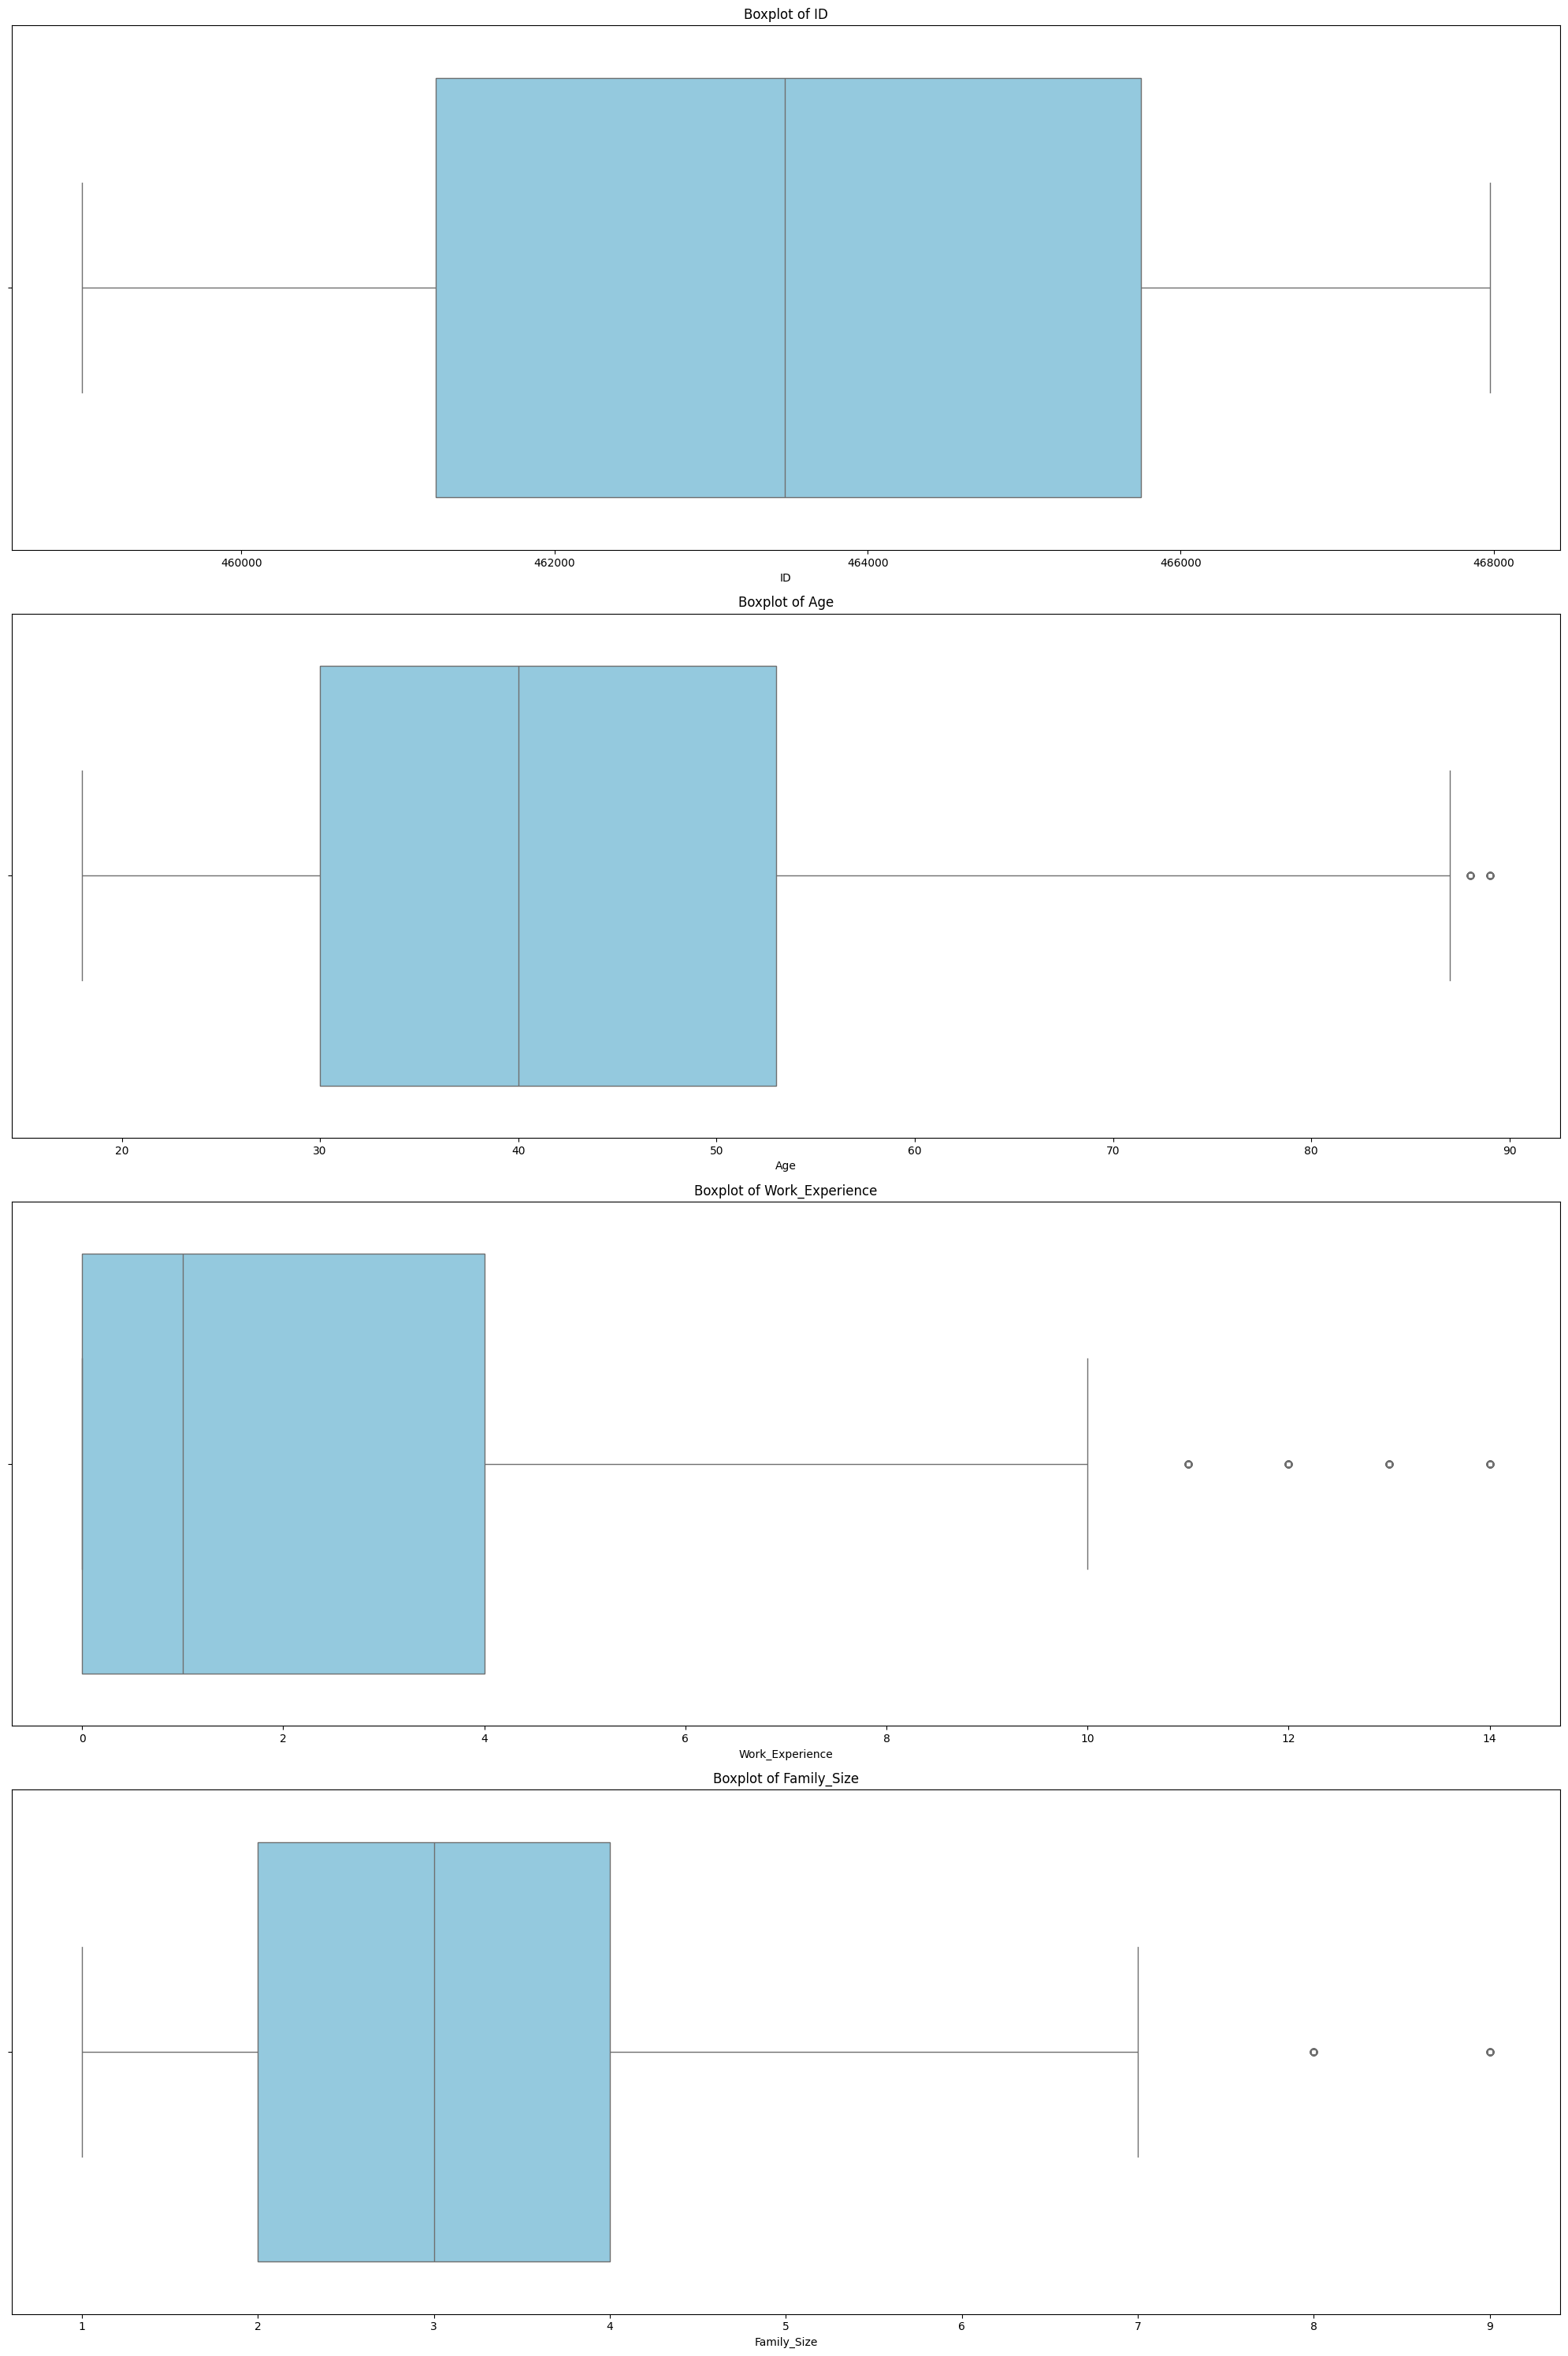

In [ ]:
#box plots for numerical data
plt.figure(figsize=(20, 30))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

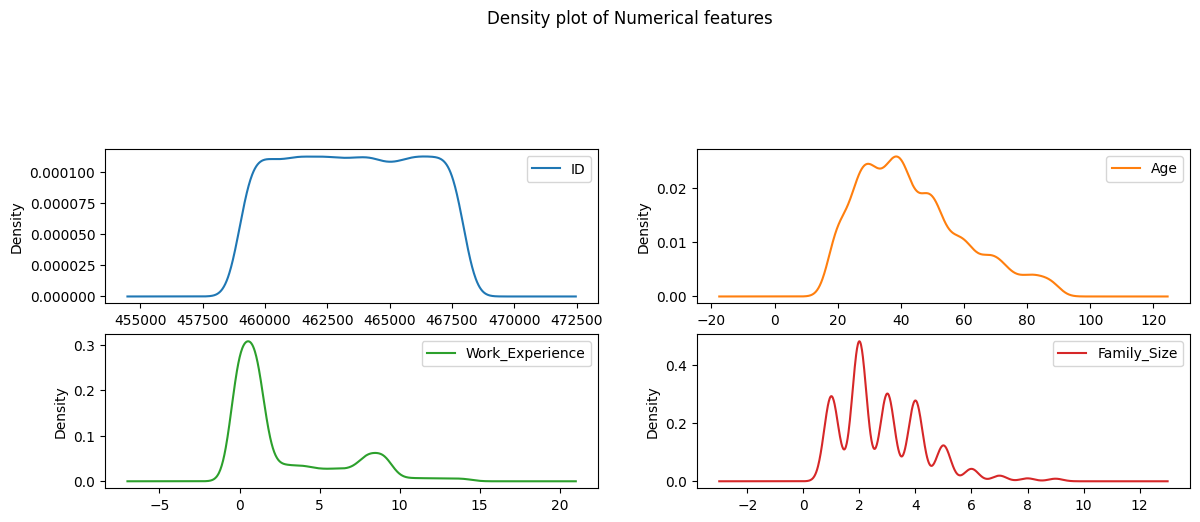

In [ ]:
#density graph for numerical data
df[numerical_cols].plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

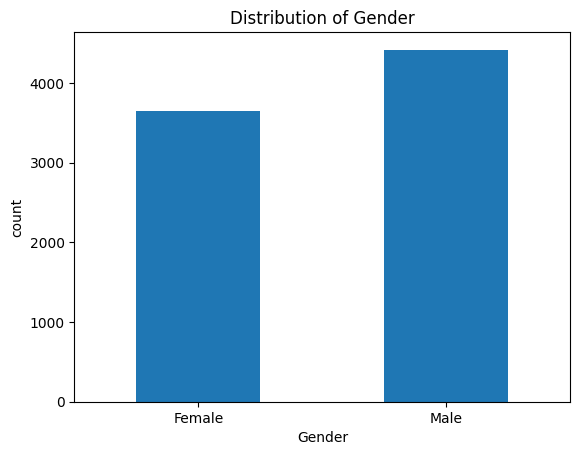

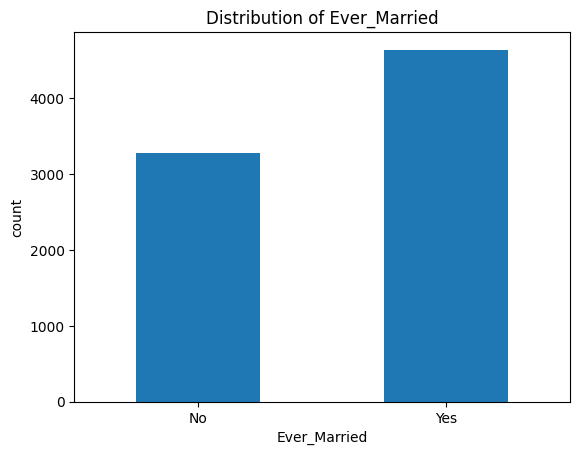

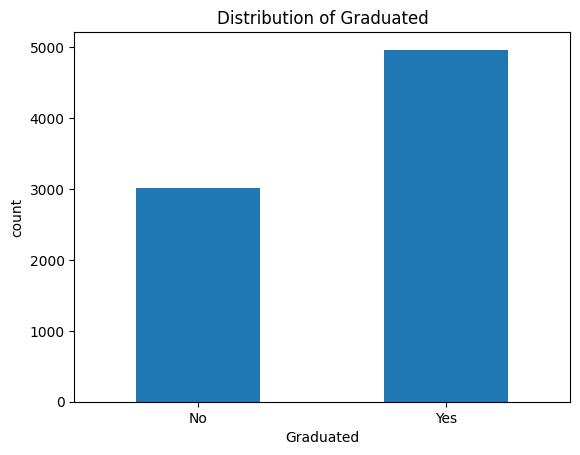

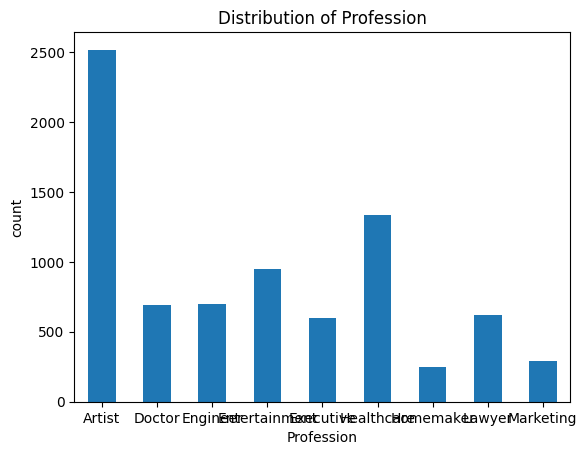

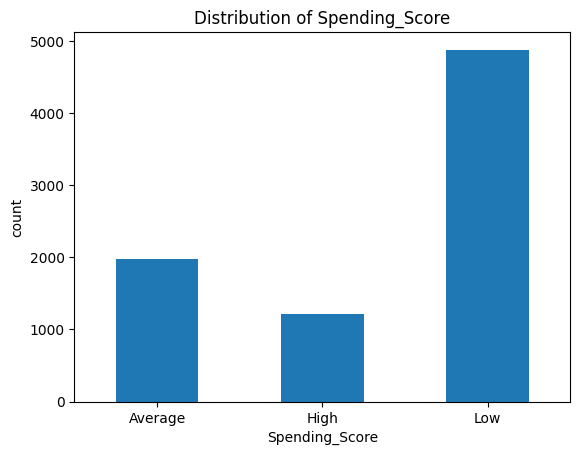

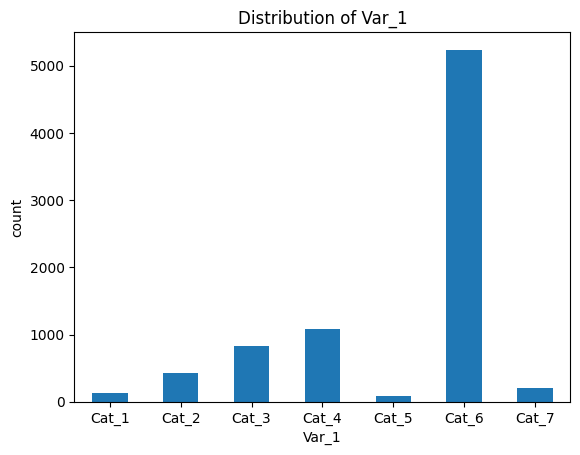

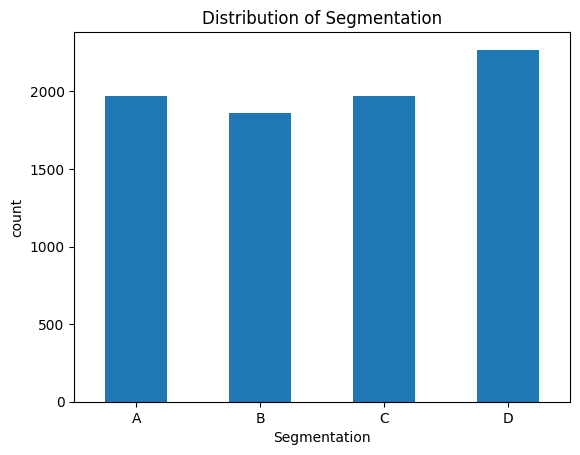

In [ ]:
#bar graphs for categorical data
for col in categorical_cols:
    plt.title(f'Distribution of {col}')
    df[col].value_counts().sort_index().plot(kind='bar', rot=0, xlabel=col,ylabel='count')
    plt.show()

Data Preprocessing and Feature Encoding

In [ ]:
#label encoding
from sklearn.preprocessing import LabelEncoder
enc = LabelEncoder()
for col in categorical_cols:
    if col != 'Profession':
        df[col] = enc.fit_transform(df[col])
#one hot encoding
df = pd.get_dummies(df, columns=["Profession"])
df.head(10)

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,462809,1,0,22,0,1.0,2,4.0,3,3,False,False,False,False,False,True,False,False,False
1,462643,0,1,38,1,NaN,0,3.0,3,0,False,False,True,False,False,False,False,False,False
2,466315,0,1,67,1,1.0,2,1.0,5,1,False,False,True,False,False,False,False,False,False
3,461735,1,1,67,1,0.0,1,2.0,5,1,False,False,False,False,False,False,False,True,False
4,462669,0,1,40,1,NaN,1,6.0,5,0,False,False,False,True,False,False,False,False,False
5,461319,1,1,56,0,0.0,0,2.0,5,2,True,False,False,False,False,False,False,False,False
6,460156,1,0,32,1,1.0,2,3.0,5,2,False,False,False,False,False,True,False,False,False
7,464347,0,0,33,1,1.0,2,3.0,5,3,False,False,False,False,False,True,False,False,False
8,465015,0,1,61,1,0.0,2,3.0,6,3,False,False,True,False,False,False,False,False,False
9,465176,0,1,55,1,1.0,0,4.0,5,2,True,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
ID,0
Gender,0
Ever_Married,0
Age,0
Graduated,0
Work_Experience,829
Spending_Score,0
Family_Size,335
Var_1,0
Segmentation,0


In [ ]:
#handle null values using imputer
from sklearn.impute import SimpleImputer

impute = SimpleImputer(missing_values=np.nan, strategy='mean')
for col in df:
    if df[col].isnull().sum() > 0:
        impute.fit(df[[col]])
        df[col] = impute.transform(df[[col]])

In [ ]:
df.head(10)

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,462809,1,0,22,0,1.000000,2,4.0,3,3,False,False,False,False,False,True,False,False,False
1,462643,0,1,38,1,2.641663,0,3.0,3,0,False,False,True,False,False,False,False,False,False
2,466315,0,1,67,1,1.000000,2,1.0,5,1,False,False,True,False,False,False,False,False,False
3,461735,1,1,67,1,0.000000,1,2.0,5,1,False,False,False,False,False,False,False,True,False
4,462669,0,1,40,1,2.641663,1,6.0,5,0,False,False,False,True,False,False,False,False,False
5,461319,1,1,56,0,0.000000,0,2.0,5,2,True,False,False,False,False,False,False,False,False
6,460156,1,0,32,1,1.000000,2,3.0,5,2,False,False,False,False,False,True,False,False,False
7,464347,0,0,33,1,1.000000,2,3.0,5,3,False,False,False,False,False,True,False,False,False
8,465015,0,1,61,1,0.000000,2,3.0,6,3,False,False,True,False,False,False,False,False,False
9,465176,0,1,55,1,1.000000,0,4.0,5,2,True,False,False,False,False,False,False,False,False


In [ ]:
#correlation matrix
df.corr()

,ID,Gender,Ever_Married,Age,Graduated,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
ID,1.000000,0.006155,0.025803,-0.005055,-0.003741,-0.028876,-0.018949,0.011514,-0.003854,-0.009104,-0.011282,-0.000394,0.019759,-0.002043,0.015769,0.006422,0.014395,-0.018744,-0.012036
Gender,0.006155,1.000000,0.099115,0.030216,-0.030436,-0.056732,-0.054261,0.054702,0.026882,0.026403,-0.040014,0.006544,-0.214829,0.136387,0.227074,0.030698,-0.132781,-0.023391,-0.042481
Ever_Married,0.025803,0.099115,1.000000,0.519746,0.164594,-0.082607,-0.595226,-0.066762,0.057516,-0.198147,0.152090,-0.073792,0.018971,0.017636,0.188809,-0.383529,-0.013955,0.187529,-0.086661
Age,-0.005055,0.030216,0.519746,1.000000,0.229283,-0.179361,-0.269544,-0.273291,0.164967,-0.243552,0.115237,-0.114043,-0.031729,-0.010086,0.129303,-0.442792,-0.058837,0.549588,-0.077097
Graduated,-0.003741,-0.030436,0.164594,0.229283,1.000000,0.032962,-0.147632,-0.212786,0.102349,-0.174949,0.341247,-0.028297,-0.110738,0.010203,-0.066448,-0.230493,-0.020480,0.008647,-0.081384
Work_Experience,-0.028876,-0.056732,-0.082607,-0.179361,0.032962,1.000000,0.045731,-0.058702,0.021339,0.012252,0.012767,-0.001684,-0.003955,0.011671,-0.024292,-0.006076,0.180206,-0.109722,-0.001304
Spending_Score,-0.018949,-0.054261,-0.595226,-0.269544,-0.147632,0.045731,1.000000,-0.112785,-0.031341,0.100572,-0.206137,0.028960,-0.028357,-0.034730,-0.091730,0.284733,0.009734,0.021212,0.093790
Family_Size,0.011514,0.054702,-0.066762,-0.273291,-0.212786,-0.058702,-0.112785,1.000000,-0.140833,0.190788,-0.148175,0.006281,0.026118,-0.014310,0.106804,0.235255,-0.063294,-0.167116,0.027098
Var_1,-0.003854,0.026882,0.057516,0.164967,0.102349,0.021339,-0.031341,-0.140833,1.000000,-0.017233,0.094673,-0.020091,-0.061709,-0.036707,0.033548,-0.076406,-0.031904,0.092777,-0.037481
Segmentation,-0.009104,0.026403,-0.198147,-0.243552,-0.174949,0.012252,0.100572,0.190788,-0.017233,1.000000,-0.148684,-0.013107,-0.086973,-0.108199,-0.022673,0.366234,-0.002054,-0.061604,0.089675


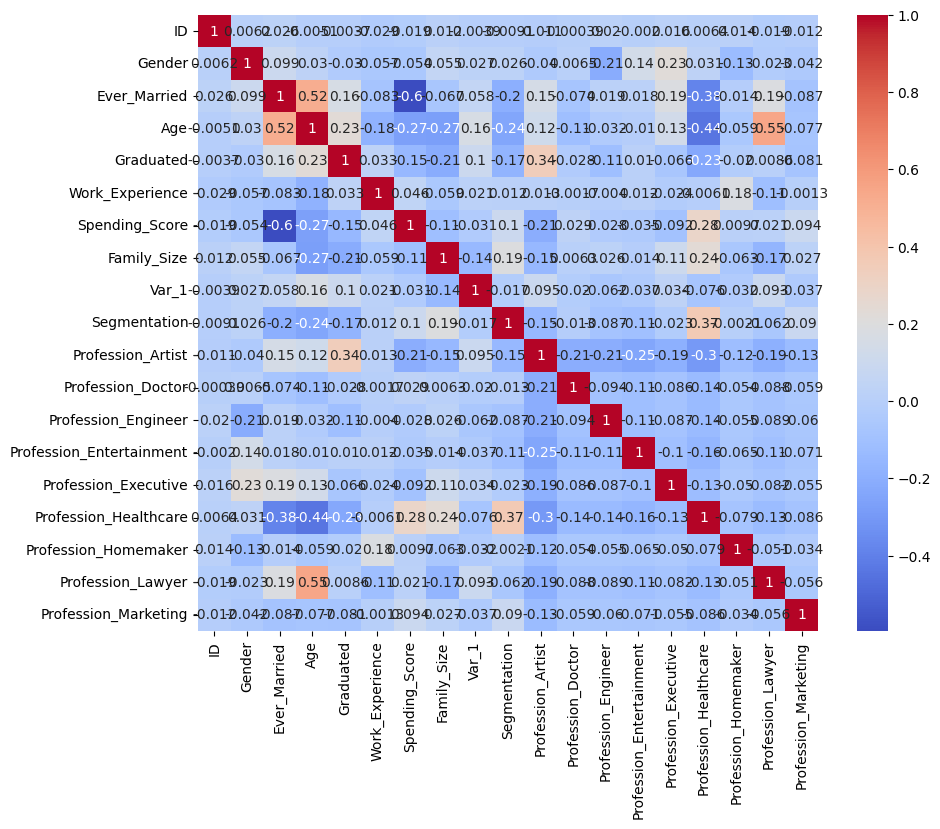

In [ ]:
#heatmap for correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
#feature deletion (using both established knowledge and correlation matrix)
to_delete = ['ID', 'Work_Experience', 'Var_1']

for col in to_delete:
    df = df.drop(col, axis=1)
df.shape

(8068, 16)

In [ ]:
#feature scaling (using standard due to a medium amount of outliers)
to_scale = ['Age']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
for col in to_scale:
    df[[col]] = scaler.fit_transform(df[[col]])
df.head(10)

,Gender,Ever_Married,Age,Graduated,Spending_Score,Family_Size,Segmentation,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,1,0,-1.284623,0,2,4.0,3,False,False,False,False,False,True,False,False,False
1,0,1,-0.327151,1,0,3.0,0,False,False,True,False,False,False,False,False,False
2,0,1,1.408268,1,2,1.0,1,False,False,True,False,False,False,False,False,False
3,1,1,1.408268,1,1,2.0,1,False,False,False,False,False,False,False,True,False
4,0,1,-0.207467,1,1,6.0,0,False,False,False,True,False,False,False,False,False
5,1,1,0.750006,0,0,2.0,2,True,False,False,False,False,False,False,False,False
6,1,0,-0.686203,1,2,3.0,2,False,False,False,False,False,True,False,False,False
7,0,0,-0.626361,1,2,3.0,3,False,False,False,False,False,True,False,False,False
8,0,1,1.049216,1,2,3.0,3,False,False,True,False,False,False,False,False,False
9,0,1,0.690164,1,0,4.0,2,True,False,False,False,False,False,False,False,False


In [ ]:
#data splitting
# Import the necessary function
from sklearn.model_selection import train_test_split

features = df.drop('Spending_Score', axis=1)
target = df['Spending_Score']

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.3, random_state=42, stratify=target)
unsupervised_train, unsupervised_test = train_test_split(df, test_size=0.3, random_state=42)

In [ ]:
#verify stratification
print(target.value_counts(normalize = True))
print(target_test.value_counts(normalize = True))
print(target_train.value_counts(normalize = True))

Spending_Score
2    0.604611
0    0.244670
1    0.150719
Name: proportion, dtype: float64
Spending_Score
2    0.604709
0    0.244527
1    0.150764
Name: proportion, dtype: float64
Spending_Score
2    0.604569
0    0.244732
1    0.150699
Name: proportion, dtype: float64


Model Training

In [ ]:
#KNeigbours
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, precision_score, f1_score, recall_score

knn = KNeighborsClassifier()
knn.fit(features_train, target_train)
target_pred_KNeighbours = knn.predict(features_test)

#evaluation scores
accuracy_Kneighbours = accuracy_score(target_test, target_pred_KNeighbours)
precision_Kneighbours = precision_score(target_test, target_pred_KNeighbours, average='weighted')
recall_Kneighbours = recall_score(target_test, target_pred_KNeighbours, average='weighted')
f1_Kneighbours = f1_score(target_test, target_pred_KNeighbours, average='weighted')
print("Accuracy:", accuracy_Kneighbours, "Precision:", precision_Kneighbours, 'Recall:', recall_Kneighbours, 'F1:', f1_Kneighbours)
print(classification_report(target_test, target_pred_KNeighbours))

Accuracy: 0.7955390334572491 Precision: 0.8090631280461098 Recall: 0.7955390334572491 F1: 0.7991828313692962
              precision    recall  f1-score   support

           0       0.63      0.79      0.70       592
           1       0.68      0.61      0.64       365
           2       0.91      0.85      0.88      1464

    accuracy                           0.80      2421
   macro avg       0.74      0.75      0.74      2421
weighted avg       0.81      0.80      0.80      2421



In [ ]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dT = DecisionTreeClassifier(random_state=42)
dT.fit(features_train, target_train)
target_pred_DT = dT.predict(features_test)

#evaluation scores
accuracy_DT = accuracy_score(target_test, target_pred_DT)
precision_DT = precision_score(target_test, target_pred_DT, average='weighted')
recall_DT = recall_score(target_test, target_pred_DT, average='weighted')
f1_DT = f1_score(target_test, target_pred_DT, average='weighted')
print("Accuracy:", accuracy_DT, 'Precision:', precision_DT, 'Recall:', recall_DT, 'F1:', f1_DT)
print(classification_report(target_test, target_pred_DT))

Accuracy: 0.7703428335398596 Precision: 0.7702094981778025 Recall: 0.7703428335398596 F1: 0.7696937982039685
              precision    recall  f1-score   support

           0       0.63      0.68      0.66       592
           1       0.61      0.54      0.57       365
           2       0.87      0.86      0.86      1464

    accuracy                           0.77      2421
   macro avg       0.70      0.69      0.70      2421
weighted avg       0.77      0.77      0.77      2421



In [ ]:
#Neural Network

from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
                    max_iter=500, random_state=42)

mlp.fit(features_train, target_train)
target_pred_NN = mlp.predict(features_test)

# evaluation scores
accuracy_NN = accuracy_score(target_test, target_pred_NN)
precision_NN = precision_score(target_test, target_pred_NN, average='weighted')
recall_NN = recall_score(target_test, target_pred_NN, average='weighted')
f1_NN = f1_score(target_test, target_pred_NN, average='weighted')
print("Accuracy:", accuracy_NN, 'Precision:', precision_NN, 'Recall:', recall_NN, 'F1:', f1_NN)
print(classification_report(target_test, target_pred_NN))


Accuracy: 0.8029739776951673 Precision: 0.8096670456021189 Recall: 0.8029739776951673 F1: 0.8016680101711638
              precision    recall  f1-score   support

           0       0.65      0.80      0.72       592
           1       0.74      0.52      0.61       365
           2       0.89      0.87      0.88      1464

    accuracy                           0.80      2421
   macro avg       0.76      0.73      0.74      2421
weighted avg       0.81      0.80      0.80      2421



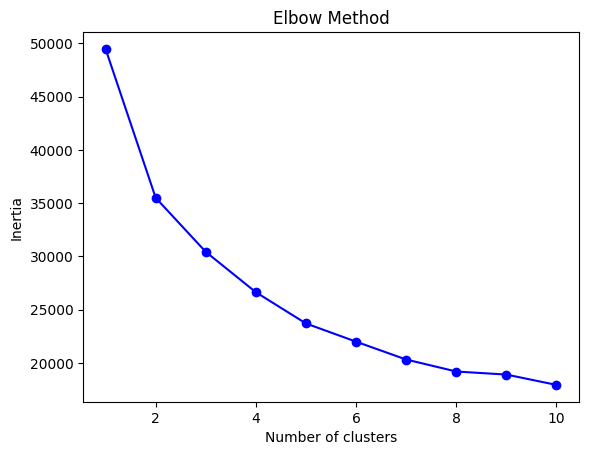

In [ ]:
#Elbow method to choose no of clusters
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)  # features only
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
#KMeans clustering (unsupervised)
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(features)

# cluster labels
cluster_labels = kmeans.labels_

# silhouette score (measures how well clusters are separated)
sil_score = silhouette_score(features, cluster_labels)
print("KMeans Silhouette Score:", sil_score)

KMeans Silhouette Score: 0.20270759673066285


Model Evaluation

In [ ]:
#collecting results for bar chart
results = {'KNeighbours': {'Accuracy':accuracy_Kneighbours, 'Precision':precision_Kneighbours, 'Recall':recall_Kneighbours, 'F1':f1_Kneighbours},
           'Decision Tree': {'Accuracy':accuracy_DT, 'Precision':precision_DT, 'Recall':recall_DT, 'F1':f1_DT},
           'MLP': {'Accuracy':accuracy_NN, 'Precision':precision_NN, 'Recall': recall_NN, 'F1':f1_NN}}

# Extract metrics
metrics = list(results["Decision Tree"].keys())
DT_scores = list(results["Decision Tree"].values())
KNeighbours_scores = list(results["KNeighbours"].values())
MLP_scores = list(results["MLP"].values())

# Bar positions
x = np.arange(len(metrics))  # metric positions
width = 0.2  # bar width

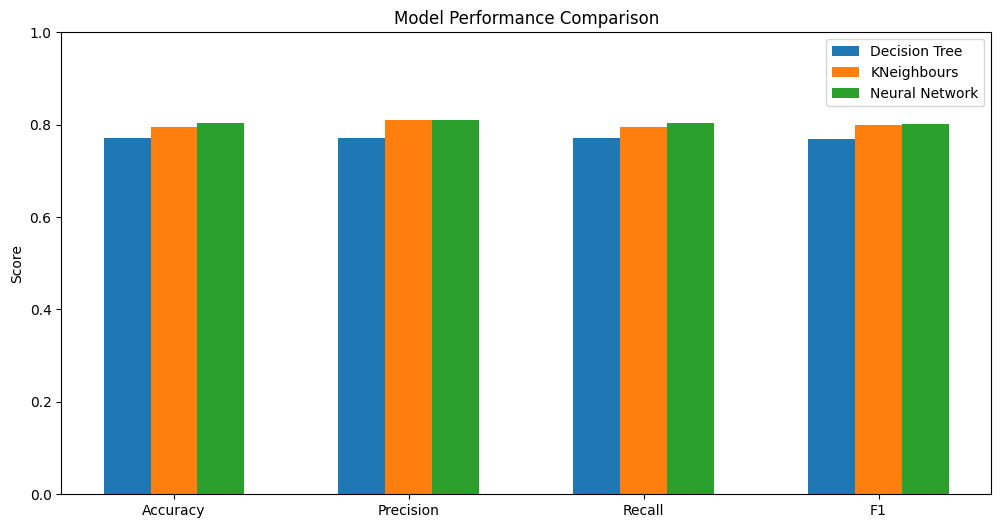

In [ ]:
#Bar chart
fig, ax = plt.subplots(figsize=(12, 6))

# Bars for DT and KNN
ax.bar(x - width, DT_scores, width, label='Decision Tree')
ax.bar(x, KNeighbours_scores, width, label='KNeighbours')
ax.bar(x+width, MLP_scores, width, label = 'Neural Network')

# Labels and formatting
ax.set_ylabel("Score")
ax.set_title("Model Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# Show chart
plt.ylim(0, 1)  # since metrics are between 0 and 1
plt.show()


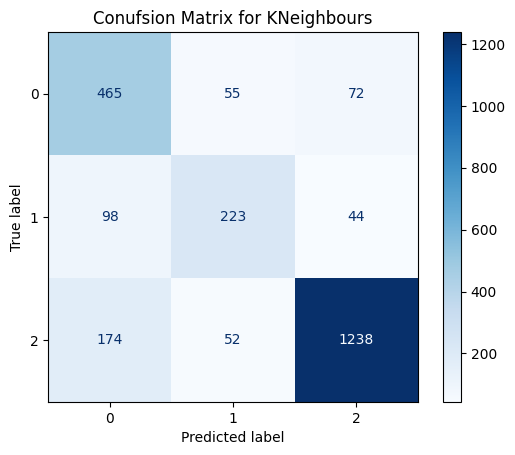

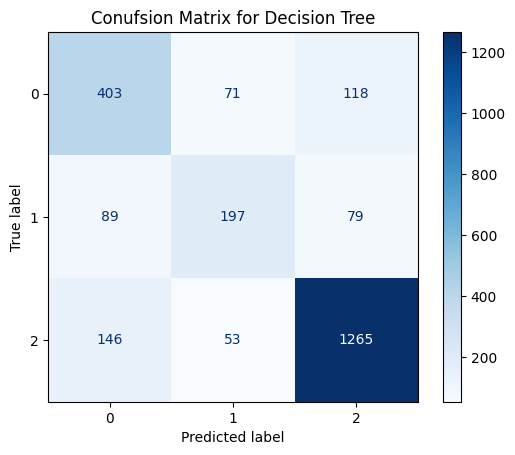

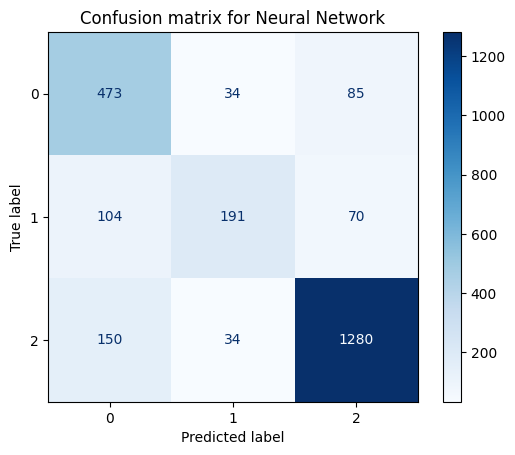

In [ ]:
#Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

#KNN
cm_KNeighbours = confusion_matrix(target_test, target_pred_KNeighbours)
disp_KNeighbours = ConfusionMatrixDisplay(confusion_matrix=cm_KNeighbours, display_labels=knn.classes_)
disp_KNeighbours.plot(cmap='Blues')
plt.title('Conufsion Matrix for KNeighbours')
plt.show()

#Decsion Tree
cm_DT = confusion_matrix(target_test, target_pred_DT)
disp_DT = ConfusionMatrixDisplay(confusion_matrix=cm_DT, display_labels=dT.classes_)
disp_DT.plot(cmap='Blues')
plt.title('Conufsion Matrix for Decision Tree')
plt.show()

#NN
cm_NN = confusion_matrix(target_test, target_pred_NN)
disp_NN = ConfusionMatrixDisplay(confusion_matrix=cm_NN, display_labels=mlp.classes_)
disp_NN.plot(cmap='Blues')
plt.title('Confusion matrix for Neural Network')
plt.show()

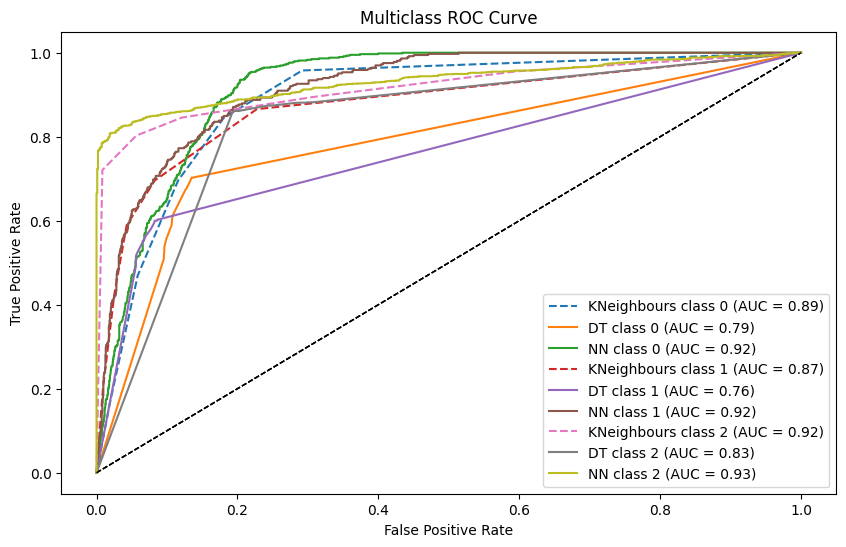

In [ ]:
#ROC curve and AUC score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(target_test)
target_test_bin = label_binarize(target_test, classes=classes)

# Probabilities from models
target_probs_KNeighbours = knn.predict_proba(features_test)
target_probs_DT = dT.predict_proba(features_test)
target_probs_NN = mlp.predict_proba(features_test)

plt.figure(figsize=(10, 6))

for i, cls in enumerate(classes):
    # KNN ROC
    fpr_KNeighbours, tpr_KNeighbours, _ = roc_curve(target_test_bin[:, i], target_probs_KNeighbours[:, i])
    auc_KNeighbours = auc(fpr_KNeighbours, tpr_KNeighbours)
    plt.plot(fpr_KNeighbours, tpr_KNeighbours, linestyle='--', label=f"KNeighbours class {cls} (AUC = {auc_KNeighbours:.2f})")

    # Decision Tree ROC
    fpr_DT, tpr_DT, _ = roc_curve(target_test_bin[:, i], target_probs_DT[:, i])
    auc_DT = auc(fpr_DT, tpr_DT)
    plt.plot(fpr_DT, tpr_DT, label=f"DT class {cls} (AUC = {auc_DT:.2f})")

    #Neural Network ROC
    fpr_NN, tpr_NN, _ = roc_curve(target_test_bin[:, i], target_probs_NN[:, i])
    auc_NN = auc(fpr_NN, tpr_NN)
    plt.plot(fpr_NN, tpr_NN, linestyle='-', label=f"NN class {cls} (AUC = {auc_NN:.2f})")
    # Diagonal line for random guess
    plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
#Evaluation for KMeans clustering
kmeans.cluster_centers_

array([[ 5.24020443e-01,  6.71890971e-01,  2.63256649e-01,
         7.24361158e-01,  1.94014206e+00,  4.57240204e-01,
         3.74105622e-01,  9.02896082e-02,  1.04258944e-01,
         1.56047700e-01,  5.28109029e-02,  3.50936968e-02,
         3.57751278e-02,  1.16183986e-01,  2.11243612e-02],
       [ 5.76691226e-01,  7.68921634e-01,  2.06785267e-02,
         6.47019424e-01,  4.87407904e+00,  1.23375754e+00,
         3.33556597e-01,  7.83657066e-02,  1.23911587e-01,
         1.30609511e-01,  1.62089752e-01,  9.31011386e-02,
         1.94239786e-02,  1.94239786e-02,  2.54521098e-02],
       [ 5.78406170e-01,  1.38817481e-01, -1.03890957e+00,
         2.66066838e-01,  3.80428302e+00,  2.85668380e+00,
         3.72750643e-02,  1.04113111e-01,  5.91259640e-02,
         6.94087404e-02,  3.02056555e-02,  5.96401028e-01,
         1.86375321e-02,  6.42673522e-04,  7.00514139e-02],
       [ 5.36468330e-01,  7.61516315e-01,  3.90120912e-01,
         7.76391555e-01,  1.96929454e+00,  2.38627639

In [ ]:
predictions=kmeans.labels_
print("Prediction for the KMeans Cluster")
print(predictions)
print(len(predictions))

Prediction for the KMeans Cluster
[2 0 0 ... 3 1 0]
8068
